# 4 Class Law LLM — Qwen3.5-9B LoRA Fine-Tuning

Fine-tunes Qwen3.5-9B on Indian Supreme Court judgments to classify each case into one of
four lifecycle categories: **Active, Repetitive, Stagnant, Dead**.

## Hardware target

RTX Pro 6000 Blackwell Server Edition (95 GB VRAM, sm_120), 176 GB system RAM, 235 GB
local disk. The notebook is tuned to use a single model copy at a time in VRAM, copy the
dataset to local disk to avoid Drive I/O on every read, and clean up between major sections.

## Dataset layout expected

```
MyDrive/FTLLM/
└── dataset/
    ├── Active/        ← .pdf files
    ├── Repetitive/    ← .pdf files
    ├── Dead/          ← .pdf files
    └── Stagnant/      ← pending_cases_india.csv
```

## What this notebook produces

1. **Trained LoRA adapter** — saved to `MyDrive/FTLLM/checkpoints/lora_adapter_final/`
2. **Evaluation report** — metrics, confusion matrices, per-class breakdown in `/content/results/`
3. **GGUF file (Q4_K_M)** — merged + quantized model for local PC use, saved to Drive and
   offered as a browser download at the end of the notebook.

## Run order

Run cells top to bottom **once**. Do not re-run baseline-eval inside a training session — it
leaves residual VRAM. To get a baseline number, run the baseline section in a fresh runtime
with `RUN_BASELINE = True` and `RUN_TRAINING = False`.


## 0. Install Dependencies

Run this cell, then **restart the runtime** before proceeding.

In [1]:
%%capture
!pip install --upgrade "transformers>=5.2.0"
!pip install --no-deps "unsloth[colab-new]@git+https://github.com/unslothai/unsloth.git"
!pip install unsloth_zoo
!pip install --no-deps trl peft accelerate bitsandbytes xformers
!pip install datasets sentencepiece protobuf scikit-learn matplotlib
!pip install pymupdf pandas
print("Packages installed. RESTART THE RUNTIME before continuing.")


## 1. Environment, Paths, and Layout Check

Sets `PYTORCH_ALLOC_CONF=expandable_segments:True` to reduce fragmentation, mounts Drive,
and verifies the dataset folders exist.


In [2]:
import os
# Must be set BEFORE torch imports anywhere
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
# Tell Unsloth to keep real logits (needed for our loss masking + GGUF export)
os.environ["UNSLOTH_RETURN_LOGITS"] = "1"

from google.colab import drive
drive.mount("/content/drive")

import json, random, gc, re, shutil, time
from pathlib import Path
from collections import Counter
import numpy as np
import torch

# ─── Paths ─────────────────────────────────────────────────────────────
DRIVE_ROOT      = "/content/drive/MyDrive/FTLLM"
DATASET_DRIVE   = f"{DRIVE_ROOT}/dataset"           # source of truth (Drive)
DATASET_LOCAL   = "/content/dataset_local"          # local cache (fast disk)
SPLITS_DIR      = f"{DRIVE_ROOT}/splits"
CKPT_DRIVE_DIR  = f"{DRIVE_ROOT}/checkpoints"
GGUF_DRIVE_DIR  = f"{DRIVE_ROOT}/gguf"
RESULTS_DIR     = "/content/results"
PROCESSED_JSONL = f"{DRIVE_ROOT}/cases_built.jsonl"

for d in (SPLITS_DIR, CKPT_DRIVE_DIR, GGUF_DRIVE_DIR, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)

# ─── Layout check (Drive side) ─────────────────────────────────────────
print("Drive layout check:")
for cls in ["Active", "Repetitive", "Dead", "Stagnant"]:
    src = f"{DATASET_DRIVE}/{cls}"
    if not os.path.isdir(src):
        print(f"  MISSING  {cls:10}  {src}")
        continue
    pdfs = list(Path(src).rglob("*.pdf")) + list(Path(src).rglob("*.PDF"))
    csvs = list(Path(src).rglob("*.csv"))
    print(f"  ok       {cls:10}  PDFs={len(pdfs):4}   CSVs={len(csvs)}")

# ─── GPU info ──────────────────────────────────────────────────────────
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"\nGPU: {props.name}   VRAM: {props.total_memory/1e9:.1f} GB")
else:
    print("\nNo CUDA GPU detected. Aborting — this notebook needs a GPU.")
    raise SystemExit


Mounted at /content/drive
Drive layout check:
  ok       Active      PDFs=  80   CSVs=0
  ok       Repetitive  PDFs=  80   CSVs=0
  ok       Dead        PDFs=  60   CSVs=0
  ok       Stagnant    PDFs=   0   CSVs=1

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition   VRAM: 102.0 GB


## 2. Cache Dataset to Local Disk

Drive I/O is ~5-10× slower than local SSD for many small PDF reads. We copy the dataset
folder to `/content/dataset_local` once; all subsequent reads hit local disk. With 235 GB
free, this is fine.


In [3]:
if os.path.exists(DATASET_LOCAL):
    print(f"Local cache already exists at {DATASET_LOCAL}")
    # Quick sanity: confirm it has the expected classes
    for cls in ["Active", "Repetitive", "Dead", "Stagnant"]:
        path = f"{DATASET_LOCAL}/{cls}"
        if not os.path.isdir(path):
            print(f"  WARNING: missing class folder {cls} in local cache — re-copy may be needed")
else:
    print(f"Copying {DATASET_DRIVE} -> {DATASET_LOCAL} (one-time)...")
    t0 = time.time()
    shutil.copytree(DATASET_DRIVE, DATASET_LOCAL)
    print(f"Done in {(time.time()-t0):.1f}s")

CLASS_DIRS = {
    "Active":     f"{DATASET_LOCAL}/Active",
    "Repetitive": f"{DATASET_LOCAL}/Repetitive",
    "Dead":       f"{DATASET_LOCAL}/Dead",
    "Stagnant":   f"{DATASET_LOCAL}/Stagnant",
}
for cls, path in CLASS_DIRS.items():
    pdfs = len(list(Path(path).rglob("*.pdf"))) + len(list(Path(path).rglob("*.PDF")))
    csvs = len(list(Path(path).rglob("*.csv")))
    print(f"  {cls:10}  PDFs={pdfs:4}  CSVs={csvs}")


Copying /content/drive/MyDrive/FTLLM/dataset -> /content/dataset_local (one-time)...
Done in 138.9s
  Active      PDFs=  80  CSVs=0
  Repetitive  PDFs=  80  CSVs=0
  Dead        PDFs=  60  CSVs=0
  Stagnant    PDFs=   0  CSVs=1


## 3. Build Unified Dataset

Walks the per-class folders, extracts disposition text from PDFs (tail-only with early stop
from the end — ~5-10× faster than reading every page), and synthesizes Stagnant text from
the CSV. Writes a JSONL to Drive for reproducibility.

Set `REBUILD = True` to force rebuild; default `False` re-uses the existing JSONL on rerun.


In [4]:
import csv
from datetime import datetime
from functools import partial
import multiprocessing as mp

try:
    import fitz  # pymupdf
except ImportError:
    raise SystemExit("Run the install cell first; pymupdf is missing.")

# ─── Settings ──────────────────────────────────────────────────────────
TAIL_CHARS_FOR_BUILD = 6000     # extract last ~6K chars per PDF
MIN_TEXT_CHARS       = 200
HEADNOTE_GUARD       = True
N_WORKERS            = 4        # parallel PDF workers
REBUILD              = False    # set True to force rebuild

# ─── Filename + date parsing ───────────────────────────────────────────
_MONTHS = {"january":1,"jan":1,"february":2,"feb":2,"march":3,"mar":3,
           "april":4,"apr":4,"may":5,"june":6,"jun":6,"july":7,"jul":7,
           "august":8,"aug":8,"september":9,"sep":9,"sept":9,
           "october":10,"oct":10,"november":11,"nov":11,"december":12,"dec":12}
_FILENAME_RE = re.compile(
    r"^(?P<head>.+?)_on_(?P<day>\d{1,2})_(?P<month>[A-Za-z]+)_(?P<year>\d{4})_\d+\.(?:pdf|PDF)$"
)
_VS_SEP_RE = re.compile(r"_vs_", re.IGNORECASE)

def parse_filename(filename):
    m = _FILENAME_RE.match(filename)
    if not m:
        title = filename.rsplit(".", 1)[0].replace("_", " ")
        return {"case_title": title, "judgment_date": None, "year": None}
    head, day_s, month_s, year_s = m.group("head"), m.group("day"), m.group("month"), m.group("year")
    day, year = int(day_s), int(year_s)
    month = _MONTHS.get(month_s.lower())
    iso = None
    if month and 1900 <= year <= 2100 and 1 <= day <= 31:
        iso = f"{year:04d}-{month:02d}-{day:02d}"
    parts = _VS_SEP_RE.split(head)
    if len(parts) >= 2:
        title = (parts[0].replace("_"," ").strip()
                 + " vs " + ("_vs_".join(parts[1:])).replace("_"," ").strip())
    else:
        title = head.replace("_", " ").strip()
    return {"case_title": title, "judgment_date": iso, "year": year}

# ─── Headnote-only detector ────────────────────────────────────────────
_HEADNOTE_ONLY_RE = re.compile(
    r"JUDGMENT\s*:?\s*[A-Z][A-Za-z0-9_.&\s]+\s+(?:vs|v\.)\s+[A-Z][A-Za-z0-9_.&\s]+"
    r"\s+on\s+\d.{0,80}Indian\s+Kanoon[\s\S]{0,200}\Z",
    re.IGNORECASE,
)
_PARA_REF_RE = re.compile(r"\[\d{2,5}[A-Z](?:[\-,]?\s*[A-Z])?\]")

def looks_like_headnote_only(text):
    if not text or len(text) > 8000:
        return False
    tail = text[-2000:]
    return bool(_HEADNOTE_ONLY_RE.search(tail)) and len(_PARA_REF_RE.findall(tail)) >= 2

# ─── Fast PDF tail extraction (read pages from back, stop early) ───────
def extract_disposition_text(pdf_path, max_chars=TAIL_CHARS_FOR_BUILD):
    parts, total_len = [], 0
    with fitz.open(pdf_path) as doc:
        for i in range(len(doc) - 1, -1, -1):
            page_text = doc.load_page(i).get_text("text")
            parts.append(page_text)
            total_len += len(page_text)
            if total_len >= max_chars * 1.5:
                break
    full = "\n".join(reversed(parts))
    return full[-max_chars:] if len(full) > max_chars else full

# ─── Date helpers ──────────────────────────────────────────────────────
TODAY = datetime.now().date()
def days_since(iso_date):
    try:
        return (TODAY - datetime.strptime(iso_date, "%Y-%m-%d").date()).days
    except Exception:
        return None

# ─── Per-PDF worker (top-level so multiprocessing can pickle it) ───────
def _process_one_pdf(args):
    pdf_path_str, category, today_iso = args
    pdf_path = Path(pdf_path_str)
    try:
        text = extract_disposition_text(pdf_path)
    except Exception as e:
        return {"_status": "error", "_reason": str(e)}
    if len(text) < MIN_TEXT_CHARS:
        return {"_status": "short"}
    if HEADNOTE_GUARD and looks_like_headnote_only(text):
        return {"_status": "headnote"}
    meta = parse_filename(pdf_path.name)
    last = meta["judgment_date"]
    return {
        "_status":              "ok",
        "case_name":            meta["case_title"],
        "category":             category,
        "text":                 text,
        "year":                 meta["year"],
        "last_date":            last,
        "ref_date":             today_iso,
        "days_since_last_date": days_since(last) if last else None,
        "is_stale_by_dates":    False,
        "source":               "pdf",
        "file_path":            str(pdf_path),
    }

def build_pdf_records(folder, category):
    pdfs = sorted(Path(folder).rglob("*.pdf")) + sorted(Path(folder).rglob("*.PDF"))
    if not pdfs:
        print(f"  {category:10} PDFs: none found in {folder}")
        return []
    today_iso = TODAY.isoformat()
    args_list = [(str(p), category, today_iso) for p in pdfs]
    t0 = time.time()
    with mp.Pool(processes=N_WORKERS) as pool:
        results = pool.map(_process_one_pdf, args_list, chunksize=4)
    records = [r for r in results if r["_status"] == "ok"]
    for r in records:
        r.pop("_status", None)
    skipped_short    = sum(1 for r in results if r["_status"] == "short")
    skipped_headnote = sum(1 for r in results if r["_status"] == "headnote")
    errors           = sum(1 for r in results if r["_status"] == "error")
    elapsed = time.time() - t0
    print(f"  {category:10} PDFs: kept={len(records):4}  short={skipped_short}  "
          f"headnote={skipped_headnote}  errors={errors}  "
          f"({elapsed:.1f}s, {len(pdfs)/max(elapsed,0.001):.1f}/s)")
    return records

# ─── Stagnant CSV → synthesized text ───────────────────────────────────
def build_stagnant_records(stagnant_dir):
    csvs = list(Path(stagnant_dir).rglob("*.csv"))
    if not csvs:
        print(f"  Stagnant   CSV: no CSV in {stagnant_dir}")
        return []
    csv_path = csvs[0]
    records = []
    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            case_name   = (row.get("case_name") or "").strip()
            court       = (row.get("court") or "").strip()
            filing_year = (row.get("filing_year") or "").strip()
            quote       = (row.get("quote") or "").strip()
            caveat      = (row.get("status_caveat") or "").strip()
            verif       = (row.get("ecourts_verification") or "").strip()
            if not case_name:
                continue
            try:
                fy = int(filing_year) if filing_year else None
            except ValueError:
                fy = None
            parts = [f"Case: {case_name}"]
            if court:        parts.append(f"Court: {court}")
            if filing_year:  parts.append(f"Filed: {filing_year}")
            if quote:        parts.append(f"Status as reported: {quote}")
            if caveat:       parts.append(f"Caveat: {caveat}")
            if verif:        parts.append(f"Verification: {verif}")
            text = "\n".join(parts)
            last_iso = f"{fy:04d}-01-01" if fy else None
            d_since = days_since(last_iso) if last_iso else None
            is_stale = d_since is not None and d_since > 365 * 5
            records.append({
                "case_name":            case_name,
                "category":             "Stagnant",
                "text":                 text,
                "year":                 fy,
                "last_date":            last_iso,
                "ref_date":             TODAY.isoformat(),
                "days_since_last_date": d_since,
                "is_stale_by_dates":    is_stale,
                "source":               "csv",
                "file_path":            str(csv_path),
            })
    print(f"  Stagnant   CSV: kept={len(records):4}")
    return records

# ─── Build (or load) ───────────────────────────────────────────────────
if REBUILD or not os.path.exists(PROCESSED_JSONL):
    print("Building dataset from per-class folders...")
    raw = []
    for cls in ["Active", "Repetitive", "Dead"]:
        raw.extend(build_pdf_records(CLASS_DIRS[cls], cls))
    raw.extend(build_stagnant_records(CLASS_DIRS["Stagnant"]))
    with open(PROCESSED_JSONL, "w", encoding="utf-8") as f:
        for r in raw:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")
    print(f"\nWrote {len(raw)} records to {PROCESSED_JSONL}")
else:
    print(f"Loading existing {PROCESSED_JSONL} (REBUILD=False)")
    with open(PROCESSED_JSONL, "r", encoding="utf-8") as f:
        raw = [json.loads(line) for line in f]

CASES_JSONL = PROCESSED_JSONL
HAS_DATES   = True

print(f"\nLoaded {len(raw)} cases")
print("Distribution:", Counter(r["category"] for r in raw))
print("Avg char length:", int(np.mean([len(r["text"]) for r in raw])))


Loading existing /content/drive/MyDrive/FTLLM/cases_built.jsonl (REBUILD=False)

Loaded 272 cases
Distribution: Counter({'Active': 80, 'Repetitive': 80, 'Dead': 60, 'Stagnant': 52})
Avg char length: 6150


## 4. Train/Validation Split and Chat Formatting

Per-class loss weights via oversampling. `HEAD_CHARS=1500, TAIL_CHARS=2500` keeps tokenized
length comfortably under `MAX_SEQ_LENGTH=2048` for most cases.


In [5]:
from datasets import Dataset

VALID_LABELS = ["Active", "Repetitive", "Stagnant", "Dead"]
SEED         = 42
VAL_FRAC     = 0.15

# Tail-priority truncation: dispositional language ("hereby dismissed", "stands
# disposed", etc.) lives at the end of judgments. Bias the budget toward the tail.
HEAD_CHARS = 1500
TAIL_CHARS = 2500   # tightened to fit MAX_SEQ_LENGTH=2048

def smart_truncate(text, head=HEAD_CHARS, tail=TAIL_CHARS):
    text = text.strip()
    if len(text) <= head + tail:
        return text
    return text[:head] + "\n\n[... middle truncated ...]\n\n" + text[-tail:]

# Per-class loss weights. Stagnant is consistently under-predicted with high
# precision; weight it up to encourage more Stagnant predictions. Repetitive
# tends to be over-predicted; weight it down slightly.
CLASS_WEIGHTS = {
    "Active":     1.0,
    "Repetitive": 0.8,
    "Stagnant":   1.5,
    "Dead":       1.3,
}

SYSTEM_PROMPT = (
    "You are a legal AI assistant specialising in Indian Supreme Court judgments. "
    "Classify the judgment into exactly one of four categories using the rules below. "
    "Apply categories in priority order: Repetitive, Stagnant, Active, Dead. "
    "First match wins.\n\n"

    "REPETITIVE\n"
    "Strong: res judicata; same cause of action; identical FIR/petition; "
    "multiplicity of proceedings; duplicate filing; already adjudicated; "
    "Order II Rule 2; Section 11 CPC; abuse of process.\n"
    "Moderate: companion or connected case; clubbed with; consolidated with; "
    "tagged with; batch matter; analogous case; lead case.\n\n"

    "STAGNANT\n"
    "Strong: adjourned sine die; kept pending indefinitely; no further progress; "
    "no effective hearing; languishing; dormant.\n"
    "Moderate: none appeared for petitioner; no steps taken; want of prosecution; "
    "matter adjourned repeatedly.\n"
    "Strong temporal signal: [IS_STALE: yes] AND no future hearing mentioned.\n\n"

    "ACTIVE\n"
    "Strong: remanded back; remitted to; sent back to court; fresh hearing; "
    "de novo trial; directed to; liberty granted; next date of hearing; "
    "listed for; partly allowed.\n"
    "Moderate: pending appeal; further orders; shall be heard; interim relief; "
    "status quo.\n\n"

    "DEAD (check the closing portion of the judgment only)\n"
    "Strong: hereby dismissed/rejected/disposed; conviction confirmed/upheld; "
    "stands disposed/closed; no merit; finally disposed; nothing survives.\n"
    "Moderate: accordingly disposed; no further orders necessary; "
    "impugned order set aside/upheld/quashed.\n\n"

    "Each input begins with date tokens: [LAST_DATE: YYYY-MM-DD] [REF_DATE: ...] "
    "[DAYS_SINCE_LAST: N] [IS_STALE: yes|no].\n\n"

    "Respond with EXACTLY: CASE TYPE: <Active|Repetitive|Stagnant|Dead>"
)

def build_date_header(rec):
    if not HAS_DATES:
        return ""
    last  = rec.get("last_date") or "unknown"
    ref   = rec.get("ref_date")  or "unknown"
    days  = rec.get("days_since_last_date")
    stale = rec.get("is_stale_by_dates", False)
    return (
        f"[LAST_DATE: {last}] [REF_DATE: {ref}] "
        f"[DAYS_SINCE_LAST: {days if days is not None else 'unknown'}] "
        f"[IS_STALE: {'yes' if stale else 'no'}]\n\n"
    )

def to_messages(rec):
    user_content = build_date_header(rec) + smart_truncate(rec["text"])
    assistant_content = f"CASE TYPE: {rec['category']}"
    return {
        "messages": [
            {"role": "system",    "content": SYSTEM_PROMPT},
            {"role": "user",      "content": user_content},
            {"role": "assistant", "content": assistant_content},
        ],
        "label":  rec["category"],
        "weight": CLASS_WEIGHTS[rec["category"]],
    }

# Stratified split
random.seed(SEED)
by_class = {lbl: [r for r in raw if r["category"] == lbl] for lbl in VALID_LABELS}
train_raw, val_raw = [], []
for lbl, items in by_class.items():
    random.shuffle(items)
    n_val = max(1, int(len(items) * VAL_FRAC))
    val_raw.extend(items[:n_val])
    train_raw.extend(items[n_val:])

train_msgs = [to_messages(r) for r in train_raw]
val_msgs   = [to_messages(r) for r in val_raw]
train_ds = Dataset.from_list(train_msgs)
val_ds   = Dataset.from_list(val_msgs)

print(f"Train: {len(train_ds)}   Val: {len(val_ds)}")
print("Train per class:", Counter(r["label"] for r in train_msgs))
print("Val   per class:", Counter(r["label"] for r in val_msgs))
print("Class weights:  ", CLASS_WEIGHTS)

# Cache eval inputs
val_inputs = [m["messages"][1]["content"] for m in val_msgs]
val_labels = [m["label"] for m in val_msgs]

# Persist splits to Drive
with open(f"{SPLITS_DIR}/train_data.jsonl", "w", encoding="utf-8") as f:
    for m in train_msgs: f.write(json.dumps(m, ensure_ascii=False) + "\n")
with open(f"{SPLITS_DIR}/val_data.jsonl", "w", encoding="utf-8") as f:
    for m in val_msgs:   f.write(json.dumps(m, ensure_ascii=False) + "\n")
print(f"Splits written to {SPLITS_DIR}")


Train: 232   Val: 40
Train per class: Counter({'Active': 68, 'Repetitive': 68, 'Dead': 51, 'Stagnant': 45})
Val   per class: Counter({'Active': 12, 'Repetitive': 12, 'Dead': 9, 'Stagnant': 7})
Class weights:   {'Active': 1.0, 'Repetitive': 0.8, 'Stagnant': 1.5, 'Dead': 1.3}
Splits written to /content/drive/MyDrive/FTLLM/splits


## 5. Evaluation Helpers

In [6]:
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.facecolor"] = "white"

LABEL_SET = set(VALID_LABELS)

def parse_output(text):
    case_type = "Dead"
    m = re.search(r"CASE TYPE:\s*(\w+)", text)
    if m and m.group(1) in LABEL_SET:
        case_type = m.group(1)
    return case_type

def run_inference(model, tokenizer, user_msgs, system_prompt, max_new_tokens=24, desc=""):
    from unsloth import FastLanguageModel
    FastLanguageModel.for_inference(model)
    inner = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer
    if inner.pad_token_id is None:
        inner.pad_token = inner.eos_token

    preds = []
    start = time.time()
    for i, user in enumerate(user_msgs):
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user},
        ]
        prompt = inner.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        enc = inner(prompt, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH).to("cuda")
        with torch.no_grad():
            out = model.generate(
                input_ids=enc["input_ids"],
                attention_mask=enc["attention_mask"],
                max_new_tokens=max_new_tokens,
                do_sample=False,
                use_cache=True,
                pad_token_id=inner.pad_token_id,
                eos_token_id=inner.eos_token_id,
            )
        preds.append(inner.decode(out[0][enc["input_ids"].shape[-1]:], skip_special_tokens=True))
        if (i + 1) % 10 == 0 or i == 0:
            rate = (i + 1) / (time.time() - start)
            print(f"  {desc} [{i+1}/{len(user_msgs)}]  {rate:.1f} samples/s")
    print(f"  {desc} done in {(time.time()-start)/60:.1f} min")
    return preds

def evaluate(preds, true_labels, label=""):
    pred_labels = [parse_output(p) for p in preds]
    acc = accuracy_score(true_labels, pred_labels)
    print(f"\n=== {label} ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(true_labels, pred_labels, labels=VALID_LABELS, zero_division=0))
    return {
        "label":       label,
        "accuracy":    acc,
        "pred_labels": pred_labels,
        "raw_preds":   preds,
    }

print("Eval helpers ready")


Eval helpers ready


## 6. Baseline Evaluation (optional, OFF by default)

**Important:** running baseline eval before training leaves residual VRAM that causes OOM
in the training cell. Default is `RUN_BASELINE = False`.

To get a baseline number, do one of these:
- **Skip baseline this run.** Train and save the adapter. Then start a fresh runtime,
  set `RUN_BASELINE = True` and `RUN_TRAINING = False`, and run only sections 0-6.
- Or set `RUN_BASELINE = True` here and accept the risk. The cell unloads the model after,
  but cleanup is imperfect.


In [7]:
RUN_BASELINE = True  # set to True only when you understand the VRAM impact

MAX_SEQ_LENGTH = 2048
MODEL_NAME     = "unsloth/Qwen3.5-9B"

baseline_results = None

if RUN_BASELINE:
    from unsloth import FastLanguageModel

    print("Loading base model for baseline eval...")
    base_model, base_tok = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME,
        max_seq_length=MAX_SEQ_LENGTH,
        load_in_4bit=True,
        dtype=None,
    )
    print(f"Running baseline on {len(val_inputs)} validation samples...")
    base_preds = run_inference(base_model, base_tok, val_inputs, SYSTEM_PROMPT, desc="Baseline")
    baseline_results = evaluate(base_preds, val_labels, label="Baseline (zero-shot)")
    with open(f"{RESULTS_DIR}/baseline_results.json", "w") as f:
        json.dump({k: v for k, v in baseline_results.items() if k != "raw_preds"}, f, default=str)
    del base_model, base_tok
    gc.collect(); torch.cuda.empty_cache()
    print("\nBase model unloaded")
else:
    print("Baseline eval skipped (RUN_BASELINE=False)")
    # Try to load saved baseline results from a previous run
    bp = f"{RESULTS_DIR}/baseline_results.json"
    if not os.path.exists(bp):
        bp = f"{DRIVE_ROOT}/baseline_results.json"
    if os.path.exists(bp):
        with open(bp) as f:
            baseline_results = json.load(f)
        print(f"Loaded prior baseline results from {bp}")
    else:
        print("No prior baseline_results.json found — final comparison will skip baseline")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
Loading base model for baseline eval...
==((====))==  Unsloth 2026.5.7: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/20.0M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/904 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/876 [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

Running baseline on 40 validation samples...
  Baseline [1/40]  0.1 samples/s
  Baseline [10/40]  0.4 samples/s
  Baseline [20/40]  0.6 samples/s
  Baseline [30/40]  0.7 samples/s
  Baseline [40/40]  0.8 samples/s
  Baseline done in 0.8 min

=== Baseline (zero-shot) ===
Accuracy: 0.2250
              precision    recall  f1-score   support

      Active       0.00      0.00      0.00        12
  Repetitive       0.00      0.00      0.00        12
    Stagnant       0.00      0.00      0.00         7
        Dead       0.23      1.00      0.37         9

    accuracy                           0.23        40
   macro avg       0.06      0.25      0.09        40
weighted avg       0.05      0.23      0.08        40


Base model unloaded


### VRAM Checkpoint — should be near 0 before model load

In [ ]:
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
alloc    = torch.cuda.memory_allocated() / 1e9
reserved = torch.cuda.memory_reserved() / 1e9
total    = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"VRAM: {alloc:.2f} GB allocated, {reserved:.2f} GB reserved, {total:.2f} GB total")
if alloc > 5:
    print("WARNING: significant VRAM in use before training model load. Consider restarting runtime.")


VRAM: 0.00 GB allocated, 0.00 GB reserved, 101.97 GB total


## 7. Load Model and Apply LoRA

In [ ]:
from unsloth import FastLanguageModel, is_bfloat16_supported
from unsloth.chat_templates import get_chat_template

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
    dtype=None,
)

LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.0

# Target all linear layers plus embedding and output projection so the model can
# adapt how it represents the date tokens and how it scores the final class word.
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
        "embed_tokens", "lm_head",
    ],
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
)

trainable, total = model.get_nb_trainable_parameters()
print(f"LoRA: r={LORA_R}, alpha={LORA_ALPHA}, dropout={LORA_DROPOUT}")
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

tokenizer = get_chat_template(tokenizer, chat_template="qwen-2.5")
inner_probe = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer
sample_text = inner_probe.apply_chat_template(
    train_ds[0]["messages"], tokenize=False, add_generation_prompt=False
)
print(f"Sample token length: {len(inner_probe.encode(sample_text))}")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.2: Fast Qwen3_5 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA RTX PRO 6000 Blackwell Server Edition. Num GPUs = 1. Max memory: 94.971 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/20.0M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:1348: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


LoRA: r=16, alpha=32, dropout=0.0
Trainable: 33,136,640 / 9,446,989,040 (0.35%)
Sample token length: 1681


## 8. Trainer Configuration

Class-weighted loss via oversampling. Tuned for the Blackwell card: bs=4, grad_accum=2,
effective batch=8, seq_len=2048. Cross-entropy in fp32 with these dims is ~5 GB — well
under headroom.


In [ ]:
from transformers import (
    Trainer, TrainingArguments, TrainerCallback, EarlyStoppingCallback,
)
from datasets import Dataset as HFDataset
from dataclasses import dataclass
import torch.nn as nn

inner_tok = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer
if inner_tok.pad_token_id is None:
    inner_tok.pad_token = inner_tok.eos_token

MAX_TOTAL_LEN    = MAX_SEQ_LENGTH
RESPONSE_RESERVE = 32   # guaranteed room for the assistant response

def make_masked_example(ex):
    msgs   = ex["messages"]
    weight = ex.get("weight", 1.0)
    prompt_text   = inner_tok.apply_chat_template(msgs[:-1], tokenize=False, add_generation_prompt=True)
    full_text     = inner_tok.apply_chat_template(msgs,     tokenize=False, add_generation_prompt=False)
    response_text = full_text[len(prompt_text):]

    prompt_ids = inner_tok(
        prompt_text, add_special_tokens=False,
        truncation=True, max_length=MAX_TOTAL_LEN - RESPONSE_RESERVE,
    )["input_ids"]
    response_ids = inner_tok(
        response_text, add_special_tokens=False,
        truncation=True, max_length=RESPONSE_RESERVE,
    )["input_ids"]

    if not response_ids:
        return None

    input_ids = prompt_ids + response_ids
    labels    = [-100] * len(prompt_ids) + response_ids
    return {
        "input_ids":      input_ids,
        "labels":         labels,
        "attention_mask": [1] * len(input_ids),
        "sample_weight":  weight,
    }

def build_masked(ds):
    return HFDataset.from_list([r for ex in ds if (r := make_masked_example(ex)) is not None])

# Oversample minority classes to mimic class weighting
def oversample(msgs):
    out = []
    for m in msgs:
        w = m["weight"]
        if   w >= 1.4: n = 2   # Stagnant: 1.5x -> 2 copies
        elif w >= 1.2: n = 2   # Dead:     1.3x -> 2 copies
        elif w <= 0.9: n = 1   # Repetitive: 0.8x -> 1 copy
        else:          n = 1   # Active:   1.0x -> 1 copy
        out.extend([m] * n)
    random.shuffle(out)
    return out

oversampled_train = oversample(train_msgs)
print(f"Train original: {len(train_msgs)}   oversampled: {len(oversampled_train)}")
print("New distribution:", Counter(m["label"] for m in oversampled_train))

train_ds_os = Dataset.from_list(oversampled_train)

print("Building masked datasets...")
train_tok = build_masked(train_ds_os)
val_tok   = build_masked(val_ds)
print(f"  train: {len(train_tok)}   val: {len(val_tok)}")

lens = [len(s["input_ids"]) for s in train_tok]
print(f"  Seq length: median {int(np.median(lens))}, max {max(lens)}, mean {int(np.mean(lens))}")
s = train_tok[0]
n_loss = sum(1 for x in s["labels"] if x != -100)
print(f"  Sample loss tokens: {n_loss}/{len(s['labels'])} ({100*n_loss/len(s['labels']):.1f}%)")

@dataclass
class MaskedPadCollator:
    pad_id: int
    def __call__(self, feats):
        maxlen = max(len(f["input_ids"]) for f in feats)
        out = {"input_ids": [], "labels": [], "attention_mask": [], "sample_weight": []}
        for f in feats:
            n = maxlen - len(f["input_ids"])
            out["input_ids"].append(f["input_ids"] + [self.pad_id]*n)
            out["labels"].append(f["labels"] + [-100]*n)
            out["attention_mask"].append(f["attention_mask"] + [0]*n)
            out["sample_weight"].append(f["sample_weight"])
        return {
            "input_ids":      torch.tensor(out["input_ids"]),
            "labels":         torch.tensor(out["labels"]),
            "attention_mask": torch.tensor(out["attention_mask"]),
            "sample_weight":  torch.tensor(out["sample_weight"], dtype=torch.float32),
        }

collator = MaskedPadCollator(pad_id=inner_tok.pad_token_id)

class WeightedTrainer(Trainer):
    """Standard trainer; class weighting is handled by oversampling the dataset."""
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        inputs.pop("sample_weight", None)   # not used here
        outputs = model(**inputs)
        loss = outputs.loss
        return (loss, outputs) if return_outputs else loss

OUTPUT_DIR = "/content/qwen35_legal_output"

class DriveBackupCallback(TrainerCallback):
    def __init__(self, drive_dir): self.drive_dir = drive_dir
    def on_epoch_end(self, args, state, control, **kwargs):
        epoch = int(state.epoch)
        dst = os.path.join(self.drive_dir, f"checkpoint-epoch-{epoch}")
        try:
            if os.path.exists(dst): shutil.rmtree(dst)
            shutil.copytree(args.output_dir, dst, dirs_exist_ok=True)
            print(f"Epoch {epoch} backed up to Drive")
        except Exception as e:
            print(f"Backup failed: {e}")

class LossLoggerCallback(TrainerCallback):
    def __init__(self):
        self.train_losses, self.eval_losses = [], []
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs: return
        if "loss" in logs and "eval_loss" not in logs:
            self.train_losses.append({"step": state.global_step, "loss": logs["loss"]})
        if "eval_loss" in logs:
            self.eval_losses.append({"step": state.global_step, "eval_loss": logs["eval_loss"]})

loss_logger = LossLoggerCallback()

trainer = WeightedTrainer(
    model=model,
    args=TrainingArguments(
        output_dir=OUTPUT_DIR,
        num_train_epochs=8,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=2,
        per_device_eval_batch_size=8,
        learning_rate=3e-5,
        lr_scheduler_type="cosine",
        warmup_ratio=0.1,
        weight_decay=0.01,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        tf32=True,
        logging_steps=10,
        eval_strategy="steps",
        eval_steps=25,
        save_strategy="steps",
        save_steps=25,
        save_total_limit=3,
        load_best_model_at_end=False,    # avoid end-of-training VRAM spike from model reload
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        optim="adamw_torch_fused",
        seed=SEED,
        report_to="none",
        remove_unused_columns=False,
        dataloader_num_workers=2,
        dataloader_pin_memory=True,
    ),
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=collator,
    callbacks=[
        DriveBackupCallback(CKPT_DRIVE_DIR),
        EarlyStoppingCallback(early_stopping_patience=3),
        loss_logger,
    ],
)
print("Trainer ready: class-weighted loss, 8 epochs, lr=3e-5, best-model loaded at end")


Train original: 232   oversampled: 328
New distribution: Counter({'Dead': 102, 'Stagnant': 90, 'Repetitive': 68, 'Active': 68})
Building masked datasets...
  train: 328   val: 40


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


  Seq length: median 1457, max 2024, mean 1248
  Sample loss tokens: 8/632 (1.3%)
Trainer ready: class-weighted loss, 8 epochs, lr=3e-5, best-model loaded at end


## 9. Train

This is where the actual fine-tuning happens. Expect ~10-20 minutes on the Blackwell card.


In [ ]:
props      = torch.cuda.get_device_properties(0)
start_mem  = round(torch.cuda.memory_allocated() / 1024**3, 2)
total_mem  = round(props.total_memory / 1024**3, 2)
print(f"GPU: {props.name}   VRAM before train: {start_mem}/{total_mem} GB")
print("=" * 60)

stats = trainer.train()

used_mem = round(torch.cuda.max_memory_reserved() / 1024**3, 2)
print("=" * 60)
print("Training complete")
print(f"  Time:             {stats.metrics['train_runtime']/60:.1f} min")
print(f"  Final train loss: {stats.metrics['train_loss']:.4f}")
print(f"  Peak VRAM:        {used_mem}/{total_mem} GB")


GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition   VRAM before train: 7.55/94.97 GB


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 328 | Num Epochs = 8 | Total steps = 328
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 33,136,640 of 9,446,989,040 (0.35% trained)
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
25,0.280032,0.128589
50,0.280350,0.098135
75,0.163949,0.116778
100,0.149339,0.087666
125,0.138453,0.157336
150,0.038425,0.278300
175,0.132717,0.204862


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:356: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")


...

Epoch 3 backed up to Drive


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:356: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")
/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:356: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")


Epoch 4 backed up to Drive


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:356: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")


Epoch 4 backed up to Drive
Training complete
  Time:             22.2 min
  Final train loss: 0.1693
  Peak VRAM:        36.63/94.97 GB


## 10. Loss Curves

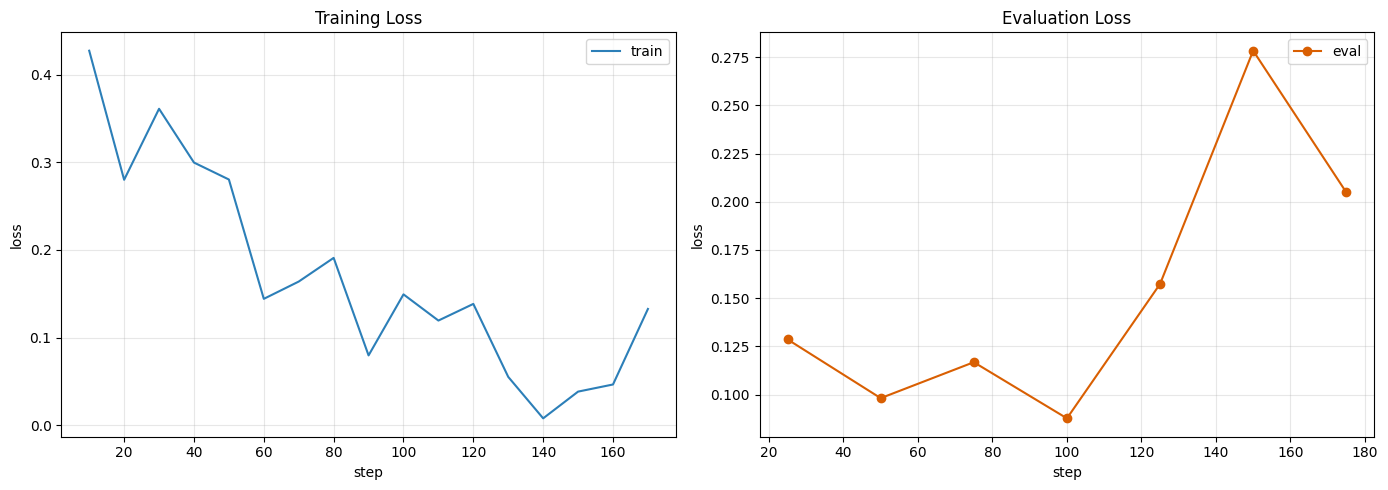

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if loss_logger.train_losses:
    s = [x["step"] for x in loss_logger.train_losses]
    l = [x["loss"] for x in loss_logger.train_losses]
    axes[0].plot(s, l, color="#2c7fb8", label="train")
    axes[0].set_title("Training Loss")
    axes[0].set_xlabel("step"); axes[0].set_ylabel("loss")
    axes[0].grid(alpha=0.3); axes[0].legend()

if loss_logger.eval_losses:
    s = [x["step"] for x in loss_logger.eval_losses]
    l = [x["eval_loss"] for x in loss_logger.eval_losses]
    axes[1].plot(s, l, marker="o", color="#d95f02", label="eval")
    axes[1].set_title("Evaluation Loss")
    axes[1].set_xlabel("step"); axes[1].set_ylabel("loss")
    axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/loss_curves.png", dpi=120)
plt.show()


## 11. Fine-tuned Evaluation

In [ ]:
ft_preds   = run_inference(model, tokenizer, val_inputs, SYSTEM_PROMPT, desc="Fine-tuned")
ft_results = evaluate(ft_preds, val_labels, label="Fine-tuned (LoRA r=16, alpha=32)")

with open(f"{RESULTS_DIR}/ft_results.json", "w") as f:
    json.dump({k: v for k, v in ft_results.items() if k != "raw_preds"}, f, default=str)


  Fine-tuned [1/40]  0.1 samples/s
  Fine-tuned [10/40]  0.7 samples/s
  Fine-tuned [20/40]  1.1 samples/s
  Fine-tuned [30/40]  1.3 samples/s
  Fine-tuned [40/40]  1.5 samples/s
  Fine-tuned done in 0.4 min

=== Fine-tuned (LoRA r=16, alpha=32) ===
Accuracy: 0.7500
              precision    recall  f1-score   support

      Active       0.77      0.83      0.80        12
  Repetitive       0.71      0.42      0.53        12
    Stagnant       1.00      1.00      1.00         7
        Dead       0.62      0.89      0.73         9

    accuracy                           0.75        40
   macro avg       0.77      0.78      0.76        40
weighted avg       0.76      0.75      0.74        40



## 12. Baseline vs Fine-tuned Comparison (if baseline available)

Note: no baseline_results available — showing fine-tuned only


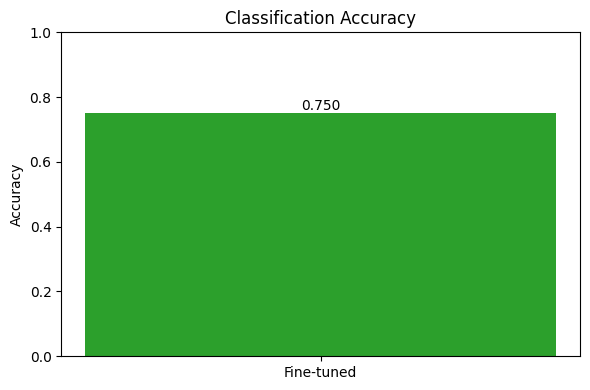

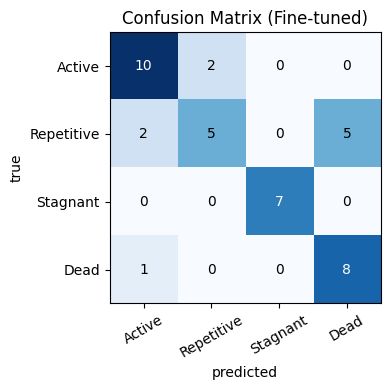

In [ ]:
from sklearn.metrics import confusion_matrix

# Always show fine-tuned results; show baseline only if available
ft_acc = ft_results["accuracy"]
if baseline_results is not None and "accuracy" in baseline_results:
    base_acc = float(baseline_results["accuracy"])
    labels = ["Baseline", "Fine-tuned"]
    accs   = [base_acc, ft_acc]
    colors = ["#bdbdbd", "#2ca02c"]
else:
    labels = ["Fine-tuned"]
    accs   = [ft_acc]
    colors = ["#2ca02c"]
    print("Note: no baseline_results available — showing fine-tuned only")

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, accs, color=colors)
plt.ylabel("Accuracy"); plt.ylim(0, 1.0); plt.title("Classification Accuracy")
for b, a in zip(bars, accs):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{a:.3f}", ha="center")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/acc_comparison.png", dpi=120); plt.show()

cm = confusion_matrix(val_labels, ft_results["pred_labels"], labels=VALID_LABELS)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(VALID_LABELS))); ax.set_xticklabels(VALID_LABELS, rotation=30)
ax.set_yticks(range(len(VALID_LABELS))); ax.set_yticklabels(VALID_LABELS)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Confusion Matrix (Fine-tuned)")
for i in range(len(VALID_LABELS)):
    for j in range(len(VALID_LABELS)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrix.png", dpi=120); plt.show()


## 13. Save LoRA Adapter to Drive

In [ ]:
ADAPTER_DIR = f"{CKPT_DRIVE_DIR}/lora_adapter_final"
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"Adapter saved to {ADAPTER_DIR}")
!du -sh {ADAPTER_DIR}


/usr/local/lib/python3.12/dist-packages/peft/utils/save_and_load.py:356: UserWarning: Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.
  warnings.warn("Setting `save_embedding_layers` to `True` as embedding layers found in `target_modules`.")
Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/FTLLM/checkpoints/lora_adapter_final/tokenizer_config.json.


Adapter saved to /content/drive/MyDrive/FTLLM/checkpoints/lora_adapter_final
4.0G	/content/drive/MyDrive/FTLLM/checkpoints/lora_adapter_final


## 14. Export to GGUF for Local PC Use

This merges the LoRA adapter back into the base model and converts to GGUF format. The
merge step temporarily uses ~36 GB VRAM; this is comfortable on your 96 GB card.

**Default quantization is Q4_K_M** (5-bit-equivalent quality, ~5.5 GB file). Alternatives
commented out: Q5_K_M (~6.5 GB, slightly higher quality), Q8_0 (~9.5 GB, near-lossless).

The resulting `.gguf` file works directly with:
- **Ollama** — `ollama create my-legal-llm -f Modelfile` (see snippet below)
- **LM Studio** — drop the file into the models folder
- **llama.cpp** — `./llama-cli -m model.gguf -p "..."`


In [ ]:
# ─── VRAM cleanup before merge ─────────────────────────────────────────
gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
alloc = torch.cuda.memory_allocated() / 1e9
total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"VRAM before GGUF export: {alloc:.2f}/{total:.2f} GB")

# ─── GGUF export (merge LoRA into base, convert, quantize) ─────────────
GGUF_LOCAL_DIR = "/content/gguf_out"
os.makedirs(GGUF_LOCAL_DIR, exist_ok=True)

# Q4_K_M is the standard balance of size vs quality
QUANT_METHOD = "q4_k_m"
# Alternatives:
# QUANT_METHOD = "q5_k_m"   # larger, slightly higher quality
# QUANT_METHOD = "q8_0"     # near-lossless, ~9.5 GB

print(f"Exporting to GGUF (quant={QUANT_METHOD}) — this can take 5-15 minutes...")
print("Steps: 1) merge LoRA into base, 2) convert to GGUF, 3) quantize.")

model.save_pretrained_gguf(
    GGUF_LOCAL_DIR,
    tokenizer,
    quantization_method=QUANT_METHOD,
)
print(f"\nGGUF written to {GGUF_LOCAL_DIR}")
!ls -lh {GGUF_LOCAL_DIR}


VRAM before GGUF export: 8.47/101.97 GB
Exporting to GGUF (quant=q4_k_m) — this can take 5-15 minutes...
Steps: 1) merge LoRA into base, 2) convert to GGUF, 3) quantize.
Unsloth: Merging model weights to 16-bit format...


Unsloth: Restored added_tokens_decoder metadata in /content/gguf_out/tokenizer_config.json.


[Unsloth merge debug] LoRA count mismatch: modules=130, lora_A=129, lora_B=129, scaling=130
[Unsloth merge debug] Total LoRA keys: 130
  key=model.language_model.embed_tokens param=None A=None B=None
  key=model.language_model.layers.0.mlp.gate_proj param=None A=(16, 4096) B=(12288, 16)
  key=model.language_model.layers.0.mlp.up_proj param=None A=(16, 4096) B=(12288, 16)
  key=model.language_model.layers.0.mlp.down_proj param=None A=(16, 12288) B=(4096, 16)
  key=model.language_model.layers.1.mlp.gate_proj param=None A=(16, 4096) B=(12288, 16)
  key=model.language_model.layers.1.mlp.up_proj param=None A=(16, 4096) B=(12288, 16)
  key=model.language_model.layers.1.mlp.down_proj param=None A=(16, 12288) B=(4096, 16)
  key=model.language_model.layers.2.mlp.gate_proj param=None A=(16, 4096) B=(12288, 16)
  key=model.language_model.layers.2.mlp.up_proj param=None A=(16, 4096) B=(12288, 16)
  key=model.language_model.layers.2.mlp.down_proj param=None A=(16, 12288) B=(4096, 16)
Found HuggingF

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Checking cache directory for required files...



Unsloth: Copying 4 files from cache to `/content/gguf_out`:   0%|          | 0/4 [00:00<?, ?it/s]
Unsloth: Copying 4 files from cache to `/content/gguf_out`:  25%|██▌       | 1/4 [00:31<01:34, 31.62s/it]
Unsloth: Copying 4 files from cache to `/content/gguf_out`:  50%|█████     | 2/4 [01:04<01:04, 32.19s/it]
Unsloth: Copying 4 files from cache to `/content/gguf_out`:  75%|███████▌  | 3/4 [01:35<00:31, 31.98s/it]
Unsloth: Copying 4 files from cache to `/content/gguf_out`: 100%|██████████| 4/4 [01:55<00:00, 28.77s/it]


Successfully copied all 4 files from cache to `/content/gguf_out`
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.



Unsloth: Preparing safetensor model files: 100%|██████████| 4/4 [00:00<00:00, 93206.76it/s]

Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [01:10<00:00, 17.69s/it]


Unsloth: Merge process complete. Saved to `/content/gguf_out`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF bf16 might take 3 minutes.
\        /    [2] Converting GGUF bf16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: Cloning llama.cpp repository...
Unsloth: Building llama.cpp - please wait 1 to 3 minutes
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...


Unsloth: [1] Converting model into bf16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/content/gguf_out_gguf/Qwen3.5-9B.BF16.gguf', '/content/gguf_out_gguf/Qwen3.5-9B.BF16-mmproj.gguf']
Unsloth: [2] Converting GGUF bf16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['/content/gguf_out_gguf/Qwen3.5-9B.Q4_K_M.gguf', '/content/gguf_out_gguf/Qwen3.5-9B.BF16-mmproj.gguf']
Unsloth: No Ollama template mapping found for model 'unsloth/Qwen3.5-9B'. Skipping Ollama Modelfile


Unsloth: example usage for Multimodal LLMs: /root/.unsloth/llama.cpp/llama-mtmd-cli -m /content/gguf_out_gguf/Qwen3.5-9B.Q4_K_M.gguf --mmproj /content/gguf_out_gguf/Qwen3.5-9B.BF16-mmproj.gguf
Unsloth: load image inside llama.cpp runner: /image test_image.jpg
Unsloth: Prompt model to describe the image

GGUF written to /content/gguf_out
total 18G
-rw-r--r-- 1 root root 2.5K May 11 

### 14a. Copy GGUF to Drive + download to your PC

The local `/content/gguf_out` resets when the runtime disconnects. Copy to Drive first so
you keep it long-term, then offer a browser download for your PC.


In [ ]:
# ─── Diagnose the GGUF failure ────────────────────────────────────────
import os, subprocess
from pathlib import Path

print("=== Disk space ===")
!df -h /content

print("\n=== What was actually written to GGUF_LOCAL_DIR ===")
if os.path.exists(GGUF_LOCAL_DIR):
    !ls -la {GGUF_LOCAL_DIR}
else:
    print(f"  {GGUF_LOCAL_DIR} does not exist")

print("\n=== llama.cpp install check ===")
# Unsloth clones llama.cpp to /content/llama.cpp typically
for candidate in ["/content/llama.cpp", "/root/llama.cpp", "./llama.cpp"]:
    if os.path.exists(candidate):
        print(f"  FOUND: {candidate}")
        !ls {candidate}/*.py 2>/dev/null | head -5
        break
else:
    print("  llama.cpp not found in standard locations")

print("\n=== VRAM state ===")
alloc = torch.cuda.memory_allocated() / 1e9
total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"  {alloc:.2f}/{total:.2f} GB allocated")

print("\n=== Model + tokenizer ready? ===")
print(f"  model exists: {model is not None}")
print(f"  tokenizer exists: {tokenizer is not None}")

=== Disk space ===
Filesystem      Size  Used Avail Use% Mounted on
overlay         236G  120G  117G  51% /

=== What was actually written to GGUF_LOCAL_DIR ===
total 18873484
drwxr-xr-x 3 root root       4096 May 11 08:05 .
drwxr-xr-x 1 root root       4096 May 11 08:09 ..
drwxr-xr-x 3 root root       4096 May 11 08:03 .cache
-rw-r--r-- 1 root root       2506 May 11 08:03 chat_template.jinja
-rw-r--r-- 1 root root       3446 May 11 08:03 config.json
-rw-r--r-- 1 root root 5276436216 May 11 08:06 model.safetensors-00001-of-00004.safetensors
-rw-r--r-- 1 root root 5335161512 May 11 08:06 model.safetensors-00002-of-00004.safetensors
-rw-r--r-- 1 root root 5368717440 May 11 08:06 model.safetensors-00003-of-00004.safetensors
-rw-r--r-- 1 root root 3325995712 May 11 08:06 model.safetensors-00004-of-00004.safetensors
-rw-r--r-- 1 root root      79657 May 11 08:03 model.safetensors.index.json
-rw-r--r-- 1 root root       1296 May 11 08:03 processor_config.json
-rw-r--r-- 1 root root       980

In [ ]:
import os

if not os.path.exists("/content/llama.cpp"):
    print("Cloning llama.cpp...")
    !git clone https://github.com/ggerganov/llama.cpp /content/llama.cpp -q
    print("Building llama.cpp (CMake, ~3-5 minutes)...")
    !cd /content/llama.cpp && cmake -B build -DGGML_CUDA=OFF -DLLAMA_CURL=OFF > /tmp/cmake.log 2>&1 || tail -20 /tmp/cmake.log
    !cd /content/llama.cpp && cmake --build build --config Release -j 8 > /tmp/build.log 2>&1 || tail -20 /tmp/build.log
    print("Installing Python deps for conversion scripts...")
    !pip install -q -r /content/llama.cpp/requirements.txt
    print("Done.")
else:
    print("llama.cpp already present at /content/llama.cpp")

# Verify the two tools we need exist
print()
print("=== Required tools ===")
for path in [
    "/content/llama.cpp/convert_hf_to_gguf.py",
    "/content/llama.cpp/build/bin/llama-quantize",
]:
    print(f"  {'OK  ' if os.path.exists(path) else 'MISS'}  {path}")

Cloning llama.cpp...
Building llama.cpp (CMake, ~3-5 minutes)...
Installing Python deps for conversion scripts...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 68.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 136.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 157.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 204.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.6/178.6 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 213.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.6/343.6 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 112.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54

In [ ]:
import os
GGUF_LOCAL_DIR = "/content/gguf_out"

# Confirm the merged HF model is still present
required_files = ["config.json", "tokenizer.json", "model.safetensors.index.json"]
for f in required_files:
    if not os.path.exists(f"{GGUF_LOCAL_DIR}/{f}"):
        raise RuntimeError(f"Merged model file missing: {GGUF_LOCAL_DIR}/{f}")
print(f"Merged HF model confirmed at {GGUF_LOCAL_DIR}")

# Step 1: Convert HF format to GGUF fp16 (CPU, ~3-5 min)
fp16_path = f"{GGUF_LOCAL_DIR}/model-f16.gguf"
print(f"\nConverting HF -> GGUF fp16...")
!python /content/llama.cpp/convert_hf_to_gguf.py {GGUF_LOCAL_DIR} \
    --outfile {fp16_path} --outtype f16

# Step 2: Quantize fp16 -> Q4_K_M (CPU, ~2-3 min)
q4_path = f"{GGUF_LOCAL_DIR}/model-q4_k_m.gguf"
print(f"\nQuantizing fp16 -> Q4_K_M...")
!/content/llama.cpp/build/bin/llama-quantize {fp16_path} {q4_path} Q4_K_M

# Step 3: Remove the intermediate fp16 file to save ~18 GB disk
if os.path.exists(fp16_path):
    os.remove(fp16_path)
    print(f"\nRemoved intermediate {fp16_path}")

# Step 4: Show what we have
print(f"\n=== Final GGUF files in {GGUF_LOCAL_DIR} ===")
!ls -lh {GGUF_LOCAL_DIR}/*.gguf

Merged HF model confirmed at /content/gguf_out

Converting HF -> GGUF fp16...
INFO:hf-to-gguf:Loading model: gguf_out
INFO:numexpr.utils:Note: NumExpr detected 48 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
INFO:numexpr.utils:NumExpr defaulting to 16 threads.
INFO:hf-to-gguf:Model architecture: Qwen3_5ForConditionalGeneration
INFO:hf-to-gguf:gguf: loading model weight map from 'model.safetensors.index.json'
INFO:hf-to-gguf:gguf: indexing model part 'model.safetensors-00001-of-00004.safetensors'
INFO:hf-to-gguf:gguf: indexing model part 'model.safetensors-00002-of-00004.safetensors'
INFO:hf-to-gguf:gguf: indexing model part 'model.safetensors-00003-of-00004.safetensors'
INFO:hf-to-gguf:gguf: indexing model part 'model.safetensors-00004-of-00004.safetensors'
INFO:gguf.gguf_writer:gguf: This GGUF file is for Little Endian only
INFO:hf-to-gguf:Exporting model...
INFO:hf-to-gguf:output.weight,                     torch.bfloat16 --> F16, shape = {4096, 248320}
INF

In [ ]:
# ─── Find the .gguf file Unsloth produced ──────────────────────────────
gguf_files = list(Path(GGUF_LOCAL_DIR).glob("*.gguf"))
if not gguf_files:
    raise RuntimeError(f"No .gguf file found in {GGUF_LOCAL_DIR}")
gguf_file = gguf_files[0]
size_gb = gguf_file.stat().st_size / 1e9
print(f"Found: {gguf_file.name}  ({size_gb:.2f} GB)")

# ─── Copy to Drive ─────────────────────────────────────────────────────
drive_target = f"{GGUF_DRIVE_DIR}/{gguf_file.name}"
print(f"Copying to Drive: {drive_target}")
t0 = time.time()
shutil.copy2(str(gguf_file), drive_target)
print(f"Copied to Drive in {(time.time()-t0):.1f}s")

# ─── Trigger browser download to your PC ───────────────────────────────
# A {size_gb:.1f}-GB download will take a while depending on your link — be patient.
from google.colab import files
print(f"\nTriggering browser download for {gguf_file.name} ({size_gb:.2f} GB)...")
print("Watch your browser's download bar.")
files.download(str(gguf_file))


Found: model-q4_k_m.gguf  (5.63 GB)
Copying to Drive: /content/drive/MyDrive/FTLLM/gguf/model-q4_k_m.gguf
Copied to Drive in 14.8s

Triggering browser download for model-q4_k_m.gguf (5.63 GB)...
Watch your browser's download bar.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 14b. Ollama Modelfile (to use the GGUF locally)

Once the `.gguf` file is on your PC, you can register it with Ollama:

```bash
# 1. Create a file named `Modelfile` in the same folder as your .gguf, with:
FROM ./your_file_name.gguf
TEMPLATE """<|im_start|>system
{{ .System }}<|im_end|>
<|im_start|>user
{{ .Prompt }}<|im_end|>
<|im_start|>assistant
"""
PARAMETER stop "<|im_end|>"
PARAMETER stop "<|im_start|>"

# 2. Register the model:
ollama create legal-4class -f Modelfile

# 3. Use it:
ollama run legal-4class
```

For LM Studio: just drop the `.gguf` into LM Studio's models folder and select it from
the dropdown. No Modelfile needed there.


# Benchmark Suite

## B1. Full Classification Metrics

In [ ]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    matthews_corrcoef, cohen_kappa_score,
    balanced_accuracy_score,
)

def full_metrics(y_true, y_pred, label=""):
    metrics = {
        "accuracy":          accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1_macro":          f1_score(y_true, y_pred, labels=VALID_LABELS, average="macro",    zero_division=0),
        "f1_weighted":       f1_score(y_true, y_pred, labels=VALID_LABELS, average="weighted", zero_division=0),
        "f1_micro":          f1_score(y_true, y_pred, labels=VALID_LABELS, average="micro",    zero_division=0),
        "precision_macro":   precision_score(y_true, y_pred, labels=VALID_LABELS, average="macro", zero_division=0),
        "recall_macro":      recall_score(y_true, y_pred, labels=VALID_LABELS, average="macro",    zero_division=0),
        "mcc":               matthews_corrcoef(y_true, y_pred),
        "cohen_kappa":       cohen_kappa_score(y_true, y_pred, labels=VALID_LABELS),
    }
    print(f"\n=== {label} ===")
    for k, v in metrics.items():
        print(f"  {k:20s} {v:.4f}")
    return metrics

base_metrics = None
# Check if baseline_results is available before attempting to compute base_metrics
if baseline_results is not None and "pred_labels" in baseline_results:
    base_metrics = full_metrics(val_labels, baseline_results["pred_labels"], "Baseline")
else:
    print("\nSkipping baseline metrics calculation as baseline_results are not available.")

ft_metrics   = full_metrics(val_labels, ft_results["pred_labels"],       "Fine-tuned")

# Prepare data for JSON dump, including baseline only if available
json_dump_data = {"fine_tuned": ft_metrics}
if base_metrics is not None:
    json_dump_data["baseline"] = base_metrics

with open(f"{RESULTS_DIR}/benchmark_metrics.json", "w") as f:
    json.dump(json_dump_data, f, indent=2)


Skipping baseline metrics calculation as baseline_results are not available.

=== Fine-tuned ===
  accuracy             0.7500
  balanced_accuracy    0.7847
  f1_macro             0.7634
  f1_weighted          0.7365
  f1_micro             0.7500
  precision_macro      0.7747
  recall_macro         0.7847
  mcc                  0.6769
  cohen_kappa          0.6650


## B2. Per-Class Breakdown

In [ ]:
import pandas as pd

def per_class_df(y_true, y_pred):
    p = precision_score(y_true, y_pred, labels=VALID_LABELS, average=None, zero_division=0)
    r = recall_score(y_true, y_pred, labels=VALID_LABELS, average=None, zero_division=0)
    f = f1_score(y_true, y_pred, labels=VALID_LABELS, average=None, zero_division=0)
    s = [sum(1 for t in y_true if t == lbl) for lbl in VALID_LABELS]
    return pd.DataFrame({"precision": p, "recall": r, "f1": f, "support": s}, index=VALID_LABELS)

print("\nBaseline:")
if baseline_results is not None and "pred_labels" in baseline_results:
    print(per_class_df(val_labels, baseline_results["pred_labels"]).round(3))
else:
    print("  Baseline results not available.")
print("\nFine-tuned:")
print(per_class_df(val_labels, ft_results["pred_labels"]).round(3))


Baseline:
  Baseline results not available.

Fine-tuned:
            precision  recall     f1  support
Active          0.769   0.833  0.800       12
Repetitive      0.714   0.417  0.526       12
Stagnant        1.000   1.000  1.000        7
Dead            0.615   0.889  0.727        9


## B3. Confusion Matrices (counts and normalised)

Note: no baseline_results available — showing fine-tuned confusion matrix only


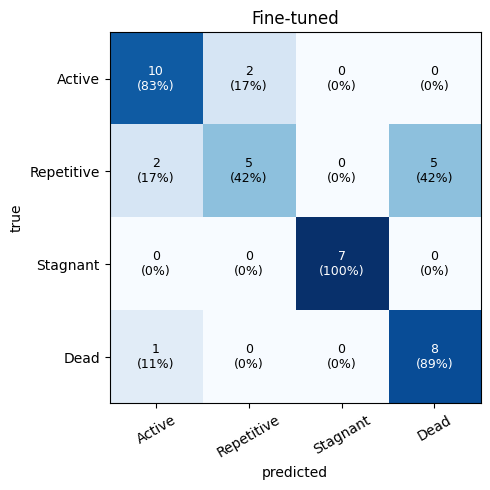

In [ ]:
def plot_cm(y_true, y_pred, ax, title):
    cm = confusion_matrix(y_true, y_pred, labels=VALID_LABELS)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(VALID_LABELS))); ax.set_xticklabels(VALID_LABELS, rotation=30)
    ax.set_yticks(range(len(VALID_LABELS))); ax.set_yticklabels(VALID_LABELS)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    for i in range(len(VALID_LABELS)):
        for j in range(len(VALID_LABELS)):
            ax.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]*100:.0f}%)",
                    ha="center", va="center",
                    color="white" if cm_norm[i, j] > 0.5 else "black", fontsize=9)

# Conditional plotting based on baseline_results availability
if baseline_results is not None and "pred_labels" in baseline_results:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    plot_cm(val_labels, baseline_results["pred_labels"], axes[0], "Baseline")
    plot_cm(val_labels, ft_results["pred_labels"],       axes[1], "Fine-tuned")
else:
    fig, ax = plt.subplots(1, 1, figsize=(6, 5)) # Single subplot if baseline is not available
    plot_cm(val_labels, ft_results["pred_labels"], ax, "Fine-tuned")
    print("Note: no baseline_results available — showing fine-tuned confusion matrix only")

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/confusion_matrices.png", dpi=120); plt.show()

## B4. Truncation Ablation

In [ ]:
def make_inputs(raw_cases, mode):
    out = []
    for r in raw_cases:
        t = r["text"].strip()
        header = build_date_header(r)
        if mode == "head":
            body = t[:HEAD_CHARS + TAIL_CHARS]
        elif mode == "tail":
            body = t[-(HEAD_CHARS + TAIL_CHARS):]
        else:
            body = smart_truncate(t)
        out.append(header + body)
    return out

ABLATION_N = min(40, len(val_raw))
sub_raw    = val_raw[:ABLATION_N]
sub_labels = [r["category"] for r in sub_raw]

ablation_results = {}
for mode in ["head", "tail", "smart"]:
    inputs = make_inputs(sub_raw, mode)
    preds = run_inference(model, tokenizer, inputs, SYSTEM_PROMPT, desc=f"ablation-{mode}")
    pred_labels = [parse_output(p) for p in preds]
    ablation_results[mode] = {
        "accuracy": accuracy_score(sub_labels, pred_labels),
        "f1_macro": f1_score(sub_labels, pred_labels, labels=VALID_LABELS, average="macro", zero_division=0),
    }

print(f"\nTruncation ablation (n={ABLATION_N}):")
for mode, m in ablation_results.items():
    print(f"  {mode:6s}  acc={m['accuracy']:.4f}  macro-F1={m['f1_macro']:.4f}")


  ablation-head [1/40]  2.5 samples/s
  ablation-head [10/40]  2.1 samples/s
  ablation-head [20/40]  2.2 samples/s
  ablation-head [30/40]  2.2 samples/s
  ablation-head [40/40]  2.3 samples/s
  ablation-head done in 0.3 min
  ablation-tail [1/40]  2.5 samples/s
  ablation-tail [10/40]  2.4 samples/s
  ablation-tail [20/40]  2.4 samples/s
  ablation-tail [30/40]  2.4 samples/s
  ablation-tail [40/40]  2.5 samples/s
  ablation-tail done in 0.3 min
  ablation-smart [1/40]  2.4 samples/s
  ablation-smart [10/40]  2.4 samples/s
  ablation-smart [20/40]  2.3 samples/s
  ablation-smart [30/40]  2.4 samples/s
  ablation-smart [40/40]  2.4 samples/s
  ablation-smart done in 0.3 min

Truncation ablation (n=40):
  head    acc=0.6250  macro-F1=0.6513
  tail    acc=0.7250  macro-F1=0.7220
  smart   acc=0.7500  macro-F1=0.7634


## B5. Year-Based Generalisation

         n  accuracy
decade              
1960s    4    1.0000
1970s    1    1.0000
1980s    3    0.6667
1990s    5    0.8000
2000s    6    0.5000
2010s    4    0.7500
2020s   17    0.7647


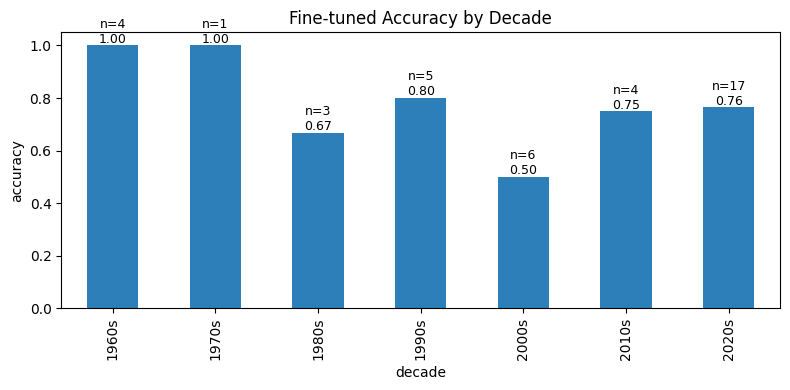

In [ ]:
def decade(y):
    try:
        return f"{(int(y)//10)*10}s"
    except Exception:
        return "unknown"

decades = [decade(r.get("year", "")) for r in val_raw]
df_years = pd.DataFrame({
    "decade":  decades,
    "true":    val_labels,
    "pred":    ft_results["pred_labels"],
})
df_years["correct"] = df_years["true"] == df_years["pred"]

by_decade = df_years.groupby("decade").agg(
    n=("correct", "size"), accuracy=("correct", "mean"),
).round(4).sort_index()
print(by_decade)

fig, ax = plt.subplots(figsize=(8, 4))
by_decade["accuracy"].plot(kind="bar", ax=ax, color="#2c7fb8")
for i, (n, a) in enumerate(zip(by_decade["n"], by_decade["accuracy"])):
    ax.text(i, a + 0.01, f"n={n}\n{a:.2f}", ha="center", fontsize=9)
ax.set_ylim(0, 1.05); ax.set_ylabel("accuracy")
ax.set_title("Fine-tuned Accuracy by Decade")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/accuracy_by_decade.png", dpi=120); plt.show()


## B6. Error Analysis

In [ ]:
errors = []
for i, (true, pred, raw) in enumerate(zip(val_labels, ft_results["pred_labels"], ft_results["raw_preds"])):
    if true != pred:
        errors.append({
            "idx":       i,
            "case_name": val_raw[i]["case_name"],
            "year":      val_raw[i].get("year", ""),
            "true":      true,
            "pred":      pred,
            "output":    raw.strip()[:200],
        })

print(f"Total errors: {len(errors)} / {len(val_labels)} ({100*len(errors)/len(val_labels):.1f}%)")
if errors:
    err_df = pd.DataFrame(errors)
    print("\nError distribution (true -> predicted):")
    print(err_df.groupby(["true", "pred"]).size().unstack(fill_value=0))
    err_df.to_csv(f"{RESULTS_DIR}/errors.csv", index=False)
    print(f"\nFull error list saved to {RESULTS_DIR}/errors.csv")


Total errors: 10 / 40 (25.0%)

Error distribution (true -> predicted):
pred        Active  Dead  Repetitive
true                                
Active           0     0           2
Dead             1     0           0
Repetitive       2     5           0

Full error list saved to /content/results/errors.csv


## B7. Summary Table

In [ ]:
summary_data = {
    "metric":     ["accuracy", "balanced_accuracy", "f1_macro", "f1_weighted", "mcc", "cohen_kappa"],
    "fine_tuned": [ft_metrics[k]   for k in ["accuracy", "balanced_accuracy", "f1_macro", "f1_weighted", "mcc", "cohen_kappa"]],
}

if base_metrics is not None:
    summary_data["baseline"] = [base_metrics[k] for k in ["accuracy", "balanced_accuracy", "f1_macro", "f1_weighted", "mcc", "cohen_kappa"]]
    summary = pd.DataFrame(summary_data)
    summary["delta"] = summary["fine_tuned"] - summary["baseline"]
else:
    summary = pd.DataFrame(summary_data)

summary = summary.round(4)
print(summary.to_string(index=False))
summary.to_csv(f"{RESULTS_DIR}/benchmark_summary.csv", index=False)

           metric  fine_tuned
         accuracy      0.7500
balanced_accuracy      0.7847
         f1_macro      0.7634
      f1_weighted      0.7365
              mcc      0.6769
      cohen_kappa      0.6650


## Final Summary

In [ ]:
print("=" * 60)
print("RUN SUMMARY")
print("=" * 60)
print(f"  Train samples       : {len(train_ds)}")
print(f"  Val samples         : {len(val_ds)}")

if baseline_results is not None and "accuracy" in baseline_results:
    print(f"  Baseline accuracy   : {baseline_results['accuracy']:.4f}")
    print(f"  Fine-tuned accuracy : {ft_results['accuracy']:.4f}")
    print(f"  Delta               : {ft_results['accuracy'] - baseline_results['accuracy']:+.4f}")
else:
    print(f"  Fine-tuned accuracy : {ft_results['accuracy']:.4f}")
    print("  Baseline accuracy   : Not available (baseline eval skipped or failed)")

print(f"  Adapter saved       : {ADAPTER_DIR}")
print("=" * 60)

RUN SUMMARY
  Train samples       : 232
  Val samples         : 40
  Fine-tuned accuracy : 0.7500
  Baseline accuracy   : Not available (baseline eval skipped or failed)
  Adapter saved       : /content/drive/MyDrive/FTLLM/checkpoints/lora_adapter_final
